In [5]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 
%matplotlib inline 

In [6]:
sum([5,6,2])

13

In [7]:
string = 'sum'

In [8]:
print(string)

sum


In [9]:
eval(string)

<function sum(iterable, /, start=0)>

In [10]:
funcaoS = eval(string)

In [11]:
funcaoS([5,6,2])

13

In [12]:
perfil = cv2.imread('perfil.jpeg')

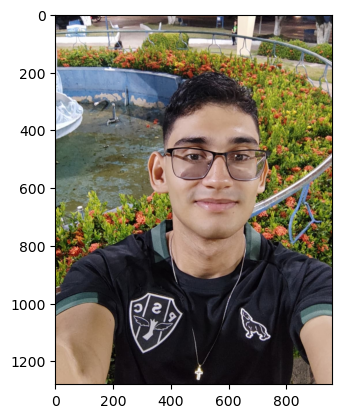

In [13]:
perfil = cv2.cvtColor(perfil, cv2.COLOR_BGR2RGB)
plt.imshow(perfil)

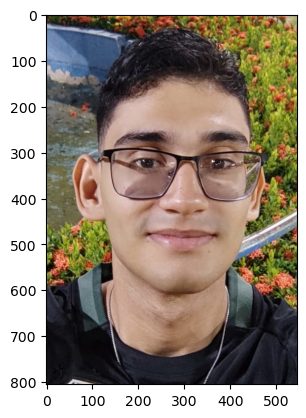

In [16]:
perfil_rosto = cv2.imread('perfil-rosto.jpeg')
perfil_rosto = cv2.cvtColor(perfil_rosto, cv2.COLOR_BGR2RGB)
plt.imshow(perfil_rosto)

In [17]:
methods = ['cv2.TM_CCOEFF', 'cv2.TM_CCOEFF_NORMED', 'cv2.TM_CCORR', 
'cv2.TM_CCORR_NORMED', 'cv2.TM_SQDIFF', 'cv2.TM_SQDIFF_NORMED']

In [18]:
perfil.shape

(1280, 958, 3)

In [19]:
perfil_rosto.shape

(805, 545, 3)

In [26]:
meu_metodo = eval('cv2.TM_CCORR')
res = cv2.matchTemplate(perfil, perfil_rosto, meu_metodo)

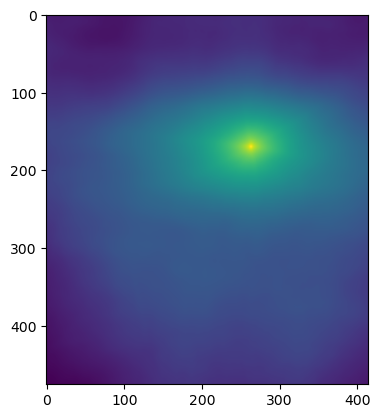

In [23]:
plt.imshow(res)

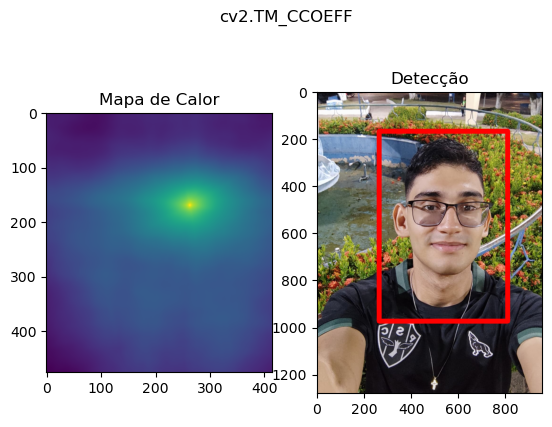

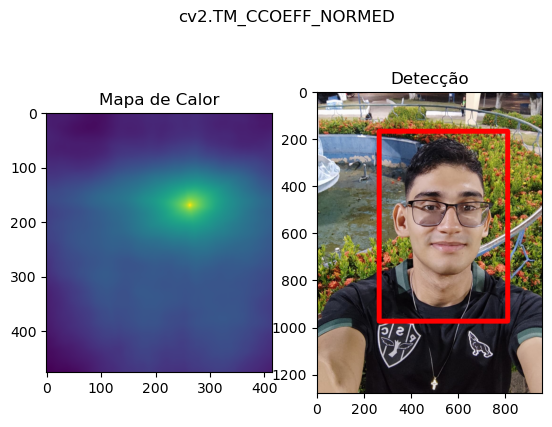

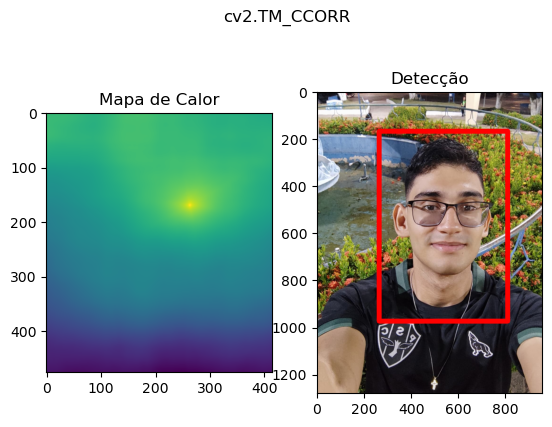

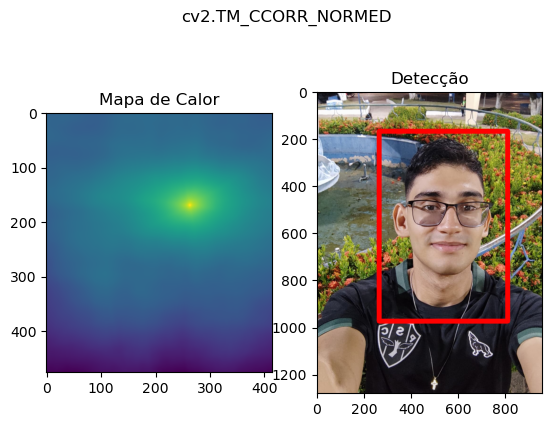

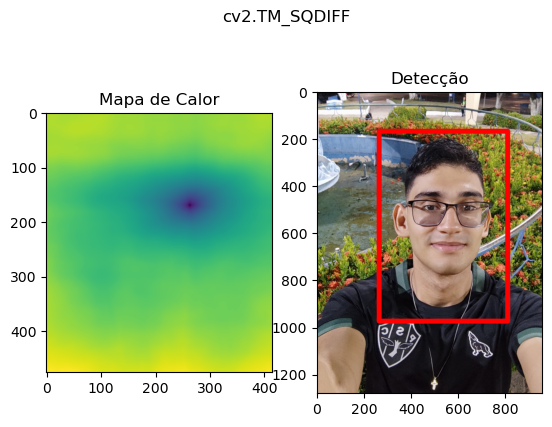

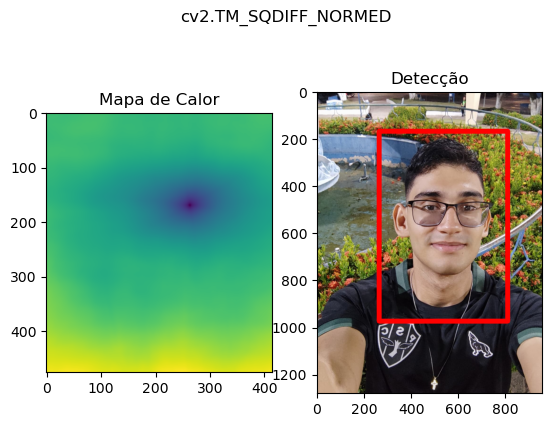

In [34]:
for m in methods:

    #Criar a cópia da imagem
    copia_perfil = perfil.copy()

    method = eval(m)

    #Template Matching
    res = cv2.matchTemplate(copia_perfil, perfil_rosto, method)

    #Posicionar os retengulos tem que pegar o valores minimos e máximos, 
    #assim como as localizações minimas e máximas

    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(res)

    if method in [cv2.TM_SQDIFF, cv2.TM_SQDIFF_NORMED]:
        top_esquerdo = min_loc #(x,y)

    else:
        top_esquerdo = max_loc
    #Definir a forma do retângulo 
    altura, largura, canais = perfil_rosto.shape

    base_direita = (top_esquerdo[0] + largura, top_esquerdo[1] + altura)

    cv2.rectangle(perfil, top_esquerdo, base_direita, (255,0,0), 20)

    #Apresentar as imagens
    plt.subplot(121)
    plt.imshow(res)
    plt.title("Mapa de Calor")

    plt.subplot(122)
    plt.imshow(perfil)
    plt.title("Detecção")

    #Nome do Método
    plt.suptitle(m)

    plt.show()

    print('\n')